In [2]:
import functools
import time
import numpy as np
import sonnet as snt
import tensorflow as tf
import tensorflow_datasets as tfds
import tqdm

print("TensorFlow version: {}".format(tf.__version__))
print("    Sonnet version: {}".format(snt.__version__))

TensorFlow version: 2.4.1
    Sonnet version: 2.0.0


In [3]:
def process_batch(images, labels):
  images = tf.squeeze(images, axis=[-1])
  images = tf.cast(images, dtype=tf.float32)
  images /= 255.
  images = tf.clip_by_value(images, 0., 1.)
  return images, labels

batch_size = 100
def mnist(split, batch_size=batch_size):
  dataset, ds_info = tfds.load('mnist:3.*.*', split=split, as_supervised=True,
                               with_info=True)
  dataset = dataset.map(process_batch)
  dataset = dataset.batch(batch_size)
  dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
  dataset = dataset.cache()
  return dataset, ds_info

mnist_train, mnist_train_info = mnist('train')
mnist_test, mnist_test_info = mnist('test')

mnist_shuffled = mnist_train.shuffle(10000).repeat()

In [4]:
class SpectralNormalizer(snt.Module):

  def __init__(self, epsilon=1e-12, name=None):
    super().__init__(name=name)
    self.l2_normalize = functools.partial(tf.math.l2_normalize, epsilon=epsilon)

  @snt.once
  def _initialize(self, weights):
    init = self.l2_normalize(snt.initializers.TruncatedNormal()(
        shape=[1, weights.shape[-1]], dtype=weights.dtype))
    # 'u' tracks our estimate of the first spectral vector for the given weight.
    self.u = tf.Variable(init, name='u', trainable=False)

  def __call__(self, weights, is_training=True):
    self._initialize(weights)
    if is_training:
      # Do a power iteration and update u and weights.
      weights_matrix = tf.reshape(weights, [-1, weights.shape[-1]])
      v = self.l2_normalize(self.u @ tf.transpose(weights_matrix))
      v_w = v @ weights_matrix
      u = self.l2_normalize(v_w)
      sigma = tf.stop_gradient(tf.reshape(v_w @ tf.transpose(u), []))
      self.u.assign(u)
      weights.assign(weights / sigma)
    return weights

In [5]:
class SpectrallyNormedLinear(snt.Linear):

  def __init__(self, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self.spectral_normalizer = SpectralNormalizer()

  def __call__(self, inputs, is_training=True):
    self._initialize(inputs)

    normed_w = self.spectral_normalizer(self.w, is_training=is_training)
    outputs = tf.matmul(inputs, normed_w)
    if self.with_bias:
      outputs = tf.add(outputs, self.b)
    return outputs

In [6]:
class SimpleBlock(snt.Module):

  def __init__(self, embed_dim, with_batch_norm=False, name=None):
    super().__init__(name=name)
    self.embed_dim = embed_dim
    self.hidden = SpectrallyNormedLinear(self.embed_dim)
    if with_batch_norm:
      self.bn = snt.BatchNorm(create_scale=True, create_offset=True)
    else:
      self.bn = None

  def __call__(self, inputs, is_training=True):
    output = self.hidden(inputs, is_training=is_training)
    if self.bn:
      output = self.bn(output, is_training=is_training)
    output = tf.nn.relu(output)
    return output

In [7]:
class Generator(snt.Module):

  def __init__(self, output_shape, num_layers=1, embed_dim=1024, name=None):
    super().__init__(name=name)
    self.layers = [
        SimpleBlock(embed_dim, with_batch_norm=True, name='block_'+str(index))
        for index in range(num_layers)
    ]
    self.output_shape = tuple(output_shape)
    output_size = np.prod(self.output_shape, dtype=int)
    self.outputs = snt.Linear(output_size, name='outputs')

  def __call__(self, inputs, is_training=True):
    inputs = tf.convert_to_tensor(inputs)
    output = snt.Flatten()(inputs)
    for layer in self.layers:
      output = layer(output, is_training=is_training)
    output = self.outputs(output)
    output = tf.reshape(output, [-1] + list(self.output_shape))
    output = tf.sigmoid(output)
    return output

In [8]:
class Discriminator(snt.Module):

  def __init__(self, num_layers=1, embed_dim=1024, name=None):
    super().__init__(name=name)
    self.layers = [
        SimpleBlock(embed_dim, with_batch_norm=False, name='block_'+str(index))
        for index in range(num_layers)
    ]
    self.outputs = SpectrallyNormedLinear(1, name='outputs')

  def __call__(self, inputs, is_training=True):
    inputs = tf.convert_to_tensor(inputs)
    output = snt.Flatten()(inputs)
    for layer in self.layers:
      output = layer(output, is_training=is_training)
    output = self.outputs(output)
    return tf.reshape(output, [-1])

In [9]:
class LittleGAN(snt.Module):

  def __init__(self, num_layers=2, embed_dim=1024, name=None):
    super().__init__(name=name)
    self.generator = Generator(
        [28, 28], num_layers=num_layers, embed_dim=embed_dim)
    self.discriminator = Discriminator(
        num_layers=num_layers, embed_dim=embed_dim)

  def generate(self, noise, is_training=True):
    return self.generator(noise, is_training=is_training)

  def discriminate(self, images):
    return self.discriminator(images)

In [10]:
gan = LittleGAN(num_layers=2)
gan

LittleGAN()

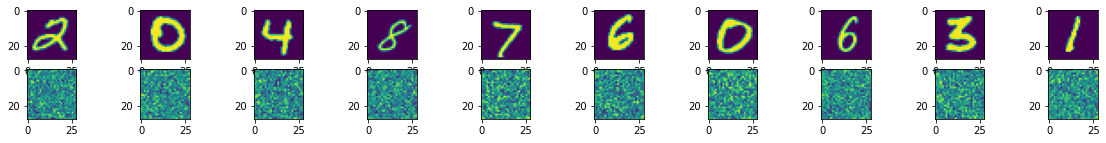

In [13]:
import matplotlib.pyplot as plt

images, labels = next(iter(mnist_test))
noise_dim = 128

def get_noise_batch(batch_size):
  noise_shape = [batch_size, noise_dim]
  return tf.random.normal(noise_shape, dtype=images.dtype)

def get_label_batch(batch_size):
  label_shape = [batch_size]
  return tf.random.uniform(label_shape, maxval=10, dtype=labels.dtype)

logits = gan.discriminate(images)
noise = get_noise_batch(images.shape[0])
gen_images = gan.generate(noise)

num_images = 10
plt.rcParams['figure.figsize'] = (2*num_images, 2)
for i in range(num_images):
  plt.subplot(2, num_images, i+1)
  plt.imshow(images[i])
  plt.subplot(2, num_images, num_images+i+1)
  plt.imshow(gen_images[i])

In [14]:
print(snt.format_variables(gan.variables))

| Variable                                                                        | Spec           | Trainable   | Device   |
|---------------------------------------------------------------------------------+----------------+-------------+----------|
| little_gan/discriminator/block_0/spectrally_normed_linear/w                     | f32[784,1024]  | True        | CPU      |
| little_gan/discriminator/block_0/spectrally_normed_linear/b                     | f32[1024]      | True        | CPU      |
| little_gan/discriminator/block_0/spectrally_normed_linear/spectral_normalizer/u | f32[1,1024]    | False       | CPU      |
| little_gan/discriminator/block_1/spectrally_normed_linear/w                     | f32[1024,1024] | True        | CPU      |
| little_gan/discriminator/block_1/spectrally_normed_linear/b                     | f32[1024]      | True        | CPU      |
| little_gan/discriminator/block_1/spectrally_normed_linear/spectral_normalizer/u | f32[1,1024]    | False       | CPU

In [15]:
def hinge_loss_disc(preds_real, preds_gen):
  loss_real = tf.reduce_mean(tf.nn.relu(1. - preds_real))
  loss_gen = tf.reduce_mean(tf.nn.relu(1. + preds_gen))
  return loss_real + loss_gen

def loss_gen(preds_gen):
  return -tf.reduce_mean(preds_gen)

class GANOptimizer(snt.Module):

  def __init__(self,
               gan,
               gen_batch_size=100,
               disc_lr=2e-4,
               gen_lr=5e-5,
               loss_type='hinge',
               num_epochs=100,
               decay_lr_start_epoch=50,
               decay_disc_lr=True,
               decay_gen_lr=True,
               name=None):
    super().__init__(name=name)
    self.gan = gan
    self.gen_batch_size = gen_batch_size
    self.init_disc_lr = disc_lr
    self.init_gen_lr = gen_lr
    self.disc_lr = tf.Variable(
        disc_lr, trainable=False, name='disc_lr', dtype=tf.float32)
    self.gen_lr = tf.Variable(
        gen_lr, trainable=False, name='gen_lr', dtype=tf.float32)
    self.disc_opt = snt.optimizers.Adam(learning_rate=self.disc_lr, beta1=0.)
    self.gen_opt = snt.optimizers.Adam(learning_rate=self.gen_lr, beta1=0.)
    self.num_epochs = tf.constant(num_epochs, dtype=tf.int32)
    self.decay_lr_start_epoch = tf.constant(decay_lr_start_epoch, dtype=tf.int32)
    self.decay_disc_lr = decay_disc_lr
    self.decay_gen_lr = decay_gen_lr

  def disc_step(self, images, labels, lr_mult=1.):
    """Updates the discriminator once on the given batch of (images, labels)."""
    del labels
    gan = self.gan
    with tf.GradientTape() as tape:
      gen_images = gan.generate(get_noise_batch(images.shape[0]))
      preds_real = gan.discriminate(images)
      preds_gen = gan.discriminate(gen_images)
      loss = hinge_loss_disc(preds_real, preds_gen)
    disc_params = gan.discriminator.trainable_variables
    disc_grads = tape.gradient(loss, disc_params)
    if self.decay_disc_lr:
      self.disc_lr.assign(self.init_disc_lr * lr_mult)
    self.disc_opt.apply(disc_grads, disc_params)
    return loss

  def gen_step(self, lr_mult=1.):
    """Updates the generator once."""
    gan = self.gan
    noise = get_noise_batch(self.gen_batch_size)
    with tf.GradientTape() as tape:
      gen_images = gan.generate(noise)
      preds_gen = gan.discriminate(gen_images)
      loss = loss_gen(preds_gen)
    gen_params = gan.generator.trainable_variables
    gen_grads = tape.gradient(loss, gen_params)
    if self.decay_gen_lr:
      self.gen_lr.assign(self.init_gen_lr * lr_mult)
    self.gen_opt.apply(gen_grads, gen_params)
    return loss

  def _get_lr_mult(self, epoch):
    # Linear decay to 0.
    decay_epoch = tf.cast(epoch - self.decay_lr_start_epoch, tf.float32)
    if decay_epoch < tf.constant(0, dtype=tf.float32):
      return tf.constant(1., dtype=tf.float32)
    num_decay_epochs = tf.cast(self.num_epochs - self.decay_lr_start_epoch,
                               dtype=tf.float32)
    return (num_decay_epochs - decay_epoch) / num_decay_epochs

  def step(self, train_batches, epoch):
    """Updates the discriminator and generator weights.

    The discriminator is updated `len(train_batches)` times and the generator is
    updated once.

    Args:
      train_batches: list of batches, where each item is an (image, label)
        tuple. The discriminator is updated on each of these batches.
      epoch: the epoch number, used to decide the learning rate multiplier for
        learning rate decay.

    Returns:
      loss: the generator loss.
      lr_mult: the computed learning rate multiplier.
    """
    lr_mult = self._get_lr_mult(epoch)
    for train_batch in train_batches:
      self.disc_step(*train_batch, lr_mult=lr_mult)
    return self.gen_step(lr_mult=lr_mult), lr_mult

In [ ]:
import tqdm

num_epochs = 25
num_disc_steps = 2

# We'll turn the step function which updates our models into a tf.function using
# autograph. This makes training much faster. If debugging, you can turn this
# off by setting `debug = True`.
debug = False

optimizer = GANOptimizer(gan, num_epochs=num_epochs)
step = optimizer.step
if not debug:
  step = tf.function(step)

train_dataset = iter(mnist_shuffled)
num_examples = mnist_train_info.splits['train'].num_examples
total_batch_size_per_step = batch_size * num_disc_steps
steps_per_epoch = num_examples // total_batch_size_per_step

steps_with_progress = tqdm.tqdm(range(num_epochs * steps_per_epoch),
                                unit='images', unit_scale=batch_size,
                                position=0)

for step_num in steps_with_progress:
  epoch = tf.constant(int(step_num / steps_per_epoch))
  train_batches = [train_dataset.next() for _ in range(num_disc_steps)]
  loss, lr_mult = step(train_batches, epoch)

  if step_num and (step_num % steps_per_epoch == 0):
    tqdm.tqdm.write(
        '\nEpoch = {}/{} (lr_mult = {:0.02f}, loss = {}) done.'.format(
            epoch.numpy(), num_epochs, lr_mult.numpy(), loss.numpy()))

print('Epoch = {}/{} (lr_mult = {:0.02f}, loss = {}) done.'.format(
    num_epochs, num_epochs, lr_mult.numpy(), loss.numpy()))

In [ ]:
num_images = 10
noise = get_noise_batch(num_images)
gen_images = gan.generate(noise)
plt.rcParams['figure.figsize'] = (num_images, 1)
for i in range(num_images):
  plt.subplot(1, num_images, i+1)
  plt.imshow(gen_images[i])